In [1]:
# Importar librerias 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Crear DF

np.random.seed(42)

fechas = pd.date_range(
    start="2015-01-01",
    periods=120,
    freq="MS"
)

tendencia = np.linspace(200, 500, 120)

estacionalidad = 50 * np.sin(2 * np.pi * np.arange(120) / 12)

ruido = np.random.normal(0, 15, 120)

ventas = tendencia + estacionalidad + ruido

df = pd.DataFrame({
    "Fecha": fechas,
    "Ventas": ventas
})

df.head()

,Fecha,Ventas
0,2015-01-01,207.450712
1,2015-02-01,225.447044
2,2015-03-01,258.058615
3,2015-04-01,280.408473
4,2015-05-01,249.873003


In [3]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index("Fecha", inplace=True)
df.head()

,Ventas
Fecha,
2015-01-01,207.450712
2015-02-01,225.447044
2015-03-01,258.058615
2015-04-01,280.408473
2015-05-01,249.873003


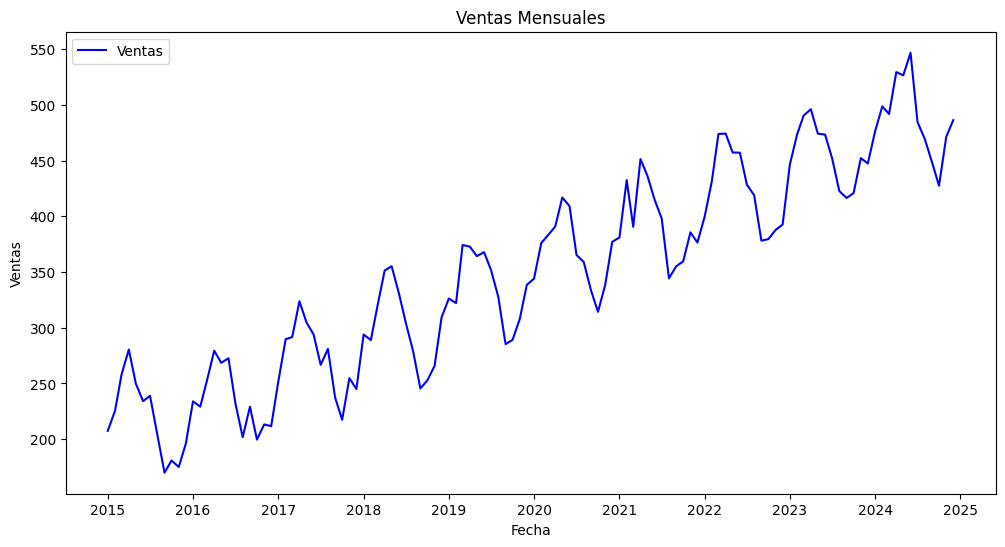

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Ventas"], label="Ventas", color="blue")
plt.title("Ventas Mensuales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()

In [5]:
train = df[:-12]
test = df[-12:]

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (108, 1), Test shape: (12, 1)


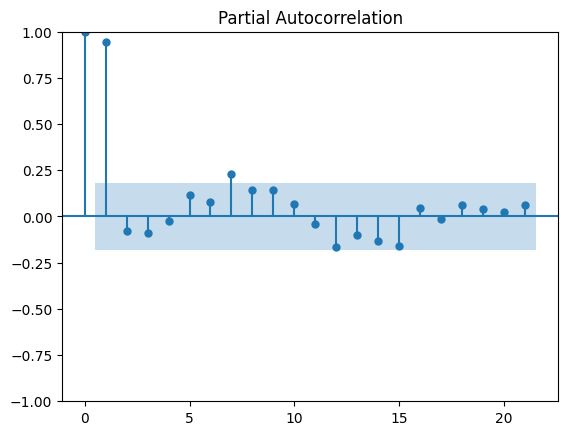

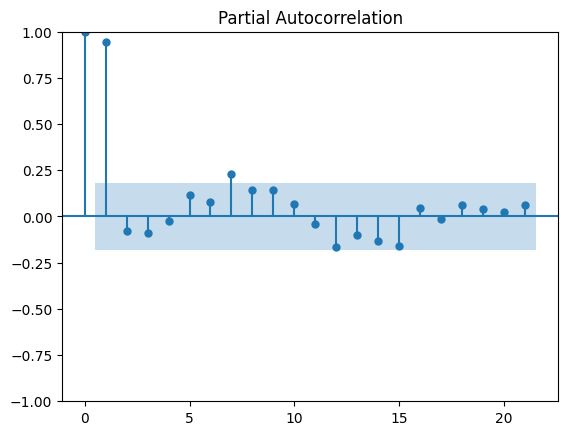

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["Ventas"])

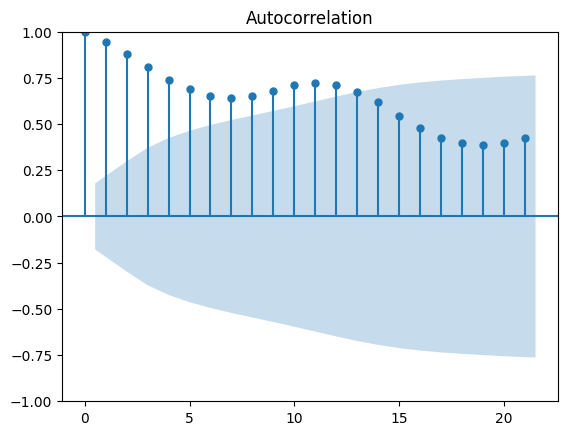

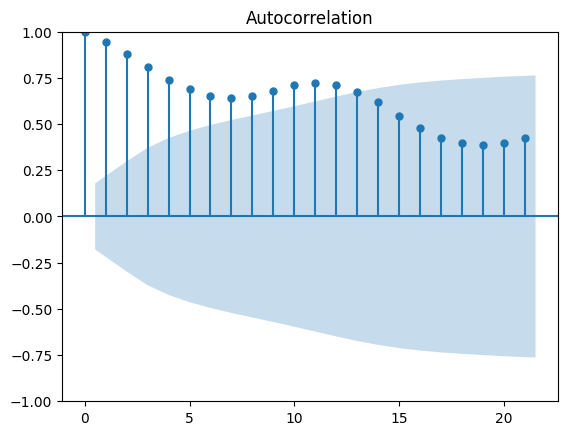

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["Ventas"])

In [8]:
# ARIMA

arima_model = ARIMA(train['Ventas'], order=(2, 1, 2)) # order: p, d, q

# Resultado del modelo ARIMA

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                 Ventas   No. Observations:                  108
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -470.604
Date:                Wed, 29 Jul 2026   AIC                            951.207
Time:                        10:25:26   BIC                            964.572
Sample:                    01-01-2015   HQIC                           956.625
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7190      0.016    104.838      0.000       1.687       1.751
ar.L2         -0.9861      0.014    -70.317      0.000      -1.014      -0.959
ma.L1         -1.8052      2.760     -0.654      0.5

2024-01-01    470.807134
2024-02-01    492.485688
2024-03-01    506.635686
2024-04-01    509.581626
2024-05-01    500.691887
2024-06-01    482.505258
2024-07-01    460.008799
2024-08-01    439.271715
2024-09-01    425.809088
2024-10-01    423.116328
2024-11-01    431.763442
2024-12-01    449.283328
Freq: MS, Name: predicted_mean, dtype: float64


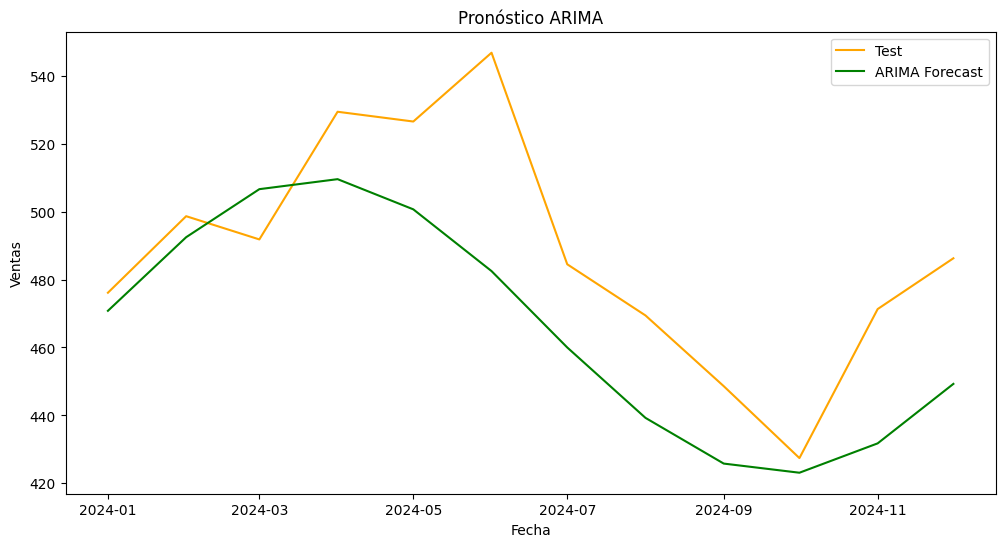

In [9]:
# Pronóstico

arima_forecast = arima_result.forecast(steps=12)
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Ventas'], label='Test', color='orange')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green')
plt.title('Pronóstico ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
print(arima_forecast)

In [10]:
# Error absoluto medio (MAE)

mae_arima = mean_absolute_error(test['Ventas'], arima_forecast)
print(f"MAE ARIMA: {mae_arima}")

MAE ARIMA: 24.557603931258537
